<a href="https://colab.research.google.com/github/OMARI7853/NLP-Project/blob/main/Sentiment_Analysis_of_Movie_Reviews_Using_the_IMDb_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Sentiment Analysis of Movie Reviews Using the IMDb Dataset

# Project Introduction
In this project, we will build a Natural Language Processing system that analyzes movie reviews from the IMDb dataset and predicts whether a review is:

- Positive
- Negative

# Problem Statement
Movie review platforms receive a large number of user opinions in text form. It is difficult to manually read and classify every review. An NLP-based sentiment analysis system can automatically determine whether a review expresses a positive or negative opinion.

# Project Aim
To develop an NLP model that classifies IMDb movie reviews as either positive or negative.


# STEP 1: Load the Dataset

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Shape of dataset
print("Dataset shape:", df.shape)

# Column names
print("Columns:", df.columns)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Dataset shape: (50000, 2)
Columns: Index(['review', 'sentiment'], dtype='object')


# STEP 2: Explore the Dataset

Dataset Information

In [ ]:
# Total number of reviews
print("Total reviews:", len(df))

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Count positive and negative reviews
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Total reviews: 50000

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


Add Review Length Column

In [ ]:
# Create a new column for review length (number of words)
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

# Show sample
df[['review', 'review_length']].head()

,review,review_length
0,One of the other reviewers has mentioned that ...,307
1,A wonderful little production. <br /><br />The...,162
2,I thought this was a wonderful way to spend ti...,166
3,Basically there's a family where a little boy ...,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",230


Average Review Length

In [ ]:
print("Average review length:", df['review_length'].mean())

Average review length: 231.15694


Summary Table

In [ ]:
summary = df.describe()
print(summary)

       review_length
count   50000.000000
mean      231.156940
std       171.343997
min         4.000000
25%       126.000000
50%       173.000000
75%       280.000000
max      2470.000000


Plot Sentiment Distribution

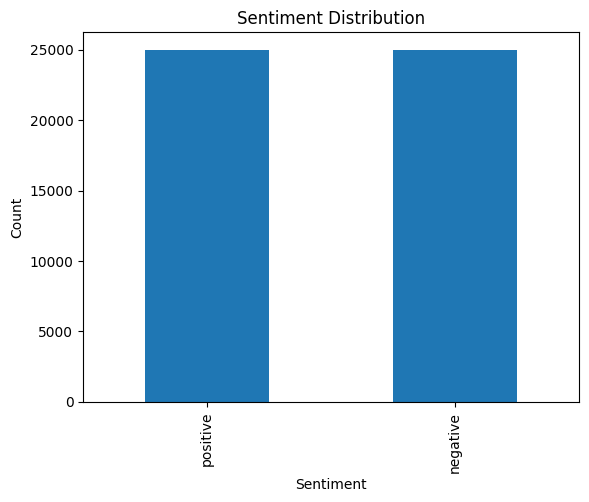

In [ ]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

The dataset contains approximately 50,000 movie reviews with no missing values detected. The sentiment distribution is balanced, with an equal number of positive and negative reviews. The average review length indicates that most reviews are relatively detailed, which is beneficial for training NLP models. A bar chart visualization confirms the balanced nature of the dataset, ensuring that the model will not be biased toward any class.

# STEP 3: Text Preprocessing

Clean the text so the model can understand it better.

In [ ]:
import re
import nltk

# Download resources (run once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Initialize Tools

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

Create Preprocessing Function

In [ ]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove punctuation & numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 4. Tokenization
    words = word_tokenize(text)

    # 5. Remove stopwords & Lemmatization
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # 6. Join words back
    return " ".join(cleaned_words)

Apply Preprocessing

In [ ]:
import nltk
nltk.download('punkt_tab')
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Show results
df[['review', 'cleaned_review']].head(5)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


Text preprocessing was performed to clean and standardize the review data. The steps included converting text to lowercase, removing HTML tags, punctuation, and numbers, tokenizing the text, removing stopwords, and applying lemmatization. This process reduced noise and improved the quality of the text data, making it more suitable for machine learning models.

# STEP 4: Convert Text into Features (TF-IDF)

Transform text into numerical features so machine learning models can understand it.

In [ ]:
# Import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

Initialize Vectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

- max_features=5000 → keep top 5000 important words

- Helps reduce computation + noise

Transform Text into Numbers

In [ ]:
X = tfidf.fit_transform(df['cleaned_review'])

# Target variable
y = df['sentiment']

In [ ]:
#Check Output
print("Feature shape:", X.shape)

Feature shape: (50000, 5000)


View Some Feature Names

In [ ]:
print(tfidf.get_feature_names_out()[:20])

['aaron' 'abandoned' 'abc' 'ability' 'able' 'absence' 'absent' 'absolute'
 'absolutely' 'absurd' 'absurdity' 'abuse' 'abused' 'abusive' 'abysmal'
 'academy' 'accent' 'accept' 'acceptable' 'acceptance']


Text data was transformed into numerical features using the TF-IDF vectorization technique. TF-IDF assigns importance to words based on their frequency in a document relative to the entire dataset. This helps reduce the impact of commonly occurring words while emphasizing more meaningful terms. The resulting feature matrix was used as input for machine learning models.

# STEP 5: Split the Dataset

Divide the dataset into:

- Training set (80%) → used to train the model

- Testing set (20%) → used to evaluate the model

In [ ]:
from sklearn.model_selection import train_test_split

Perform the Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # for reproducibility
)

In [ ]:
# Check shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (40000, 5000)
Testing set shape: (10000, 5000)


In [ ]:
# Check Labels
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training labels: (40000,)
Testing labels: (10000,)


The dataset was split into training and testing sets using an 80:20 ratio. The training set was used to train the machine learning models, while the testing set was used to evaluate their performance on unseen data. This approach helps ensure that the model generalizes well and does not overfit the training data.

# STEP 6: Train Classification Models

We will use:

- Multinomial Naive Bayes (Very fast, works well with text)

- Logistic Regression (More accurate, handles complexity better)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

Train Naive Bayes Model

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

Train Logistic Regression Model

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Why max_iter=1000?

- Logistic Regression may need more iterations to converge

- Prevents training errors

Make Predictions

In [ ]:
# Naive Bayes predictions
y_pred_nb = nb_model.predict(X_test)

# Logistic Regression predictions
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# Accuracy Check
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Naive Bayes Accuracy: 0.855
Logistic Regression Accuracy: 0.8891


Interpretation:

Naive Bayes:

- Fast but simpler assumptions

Logistic Regression:

- Learns deeper relationships → better accuracy

Two classification models were trained: Multinomial Naive Bayes and Logistic Regression. Naive Bayes is a simple probabilistic model that performs well with text data, while Logistic Regression is a more advanced model capable of capturing complex patterns. Both models were trained on the training dataset and used to make predictions on the test dataset.

# STEP 7: Model Evaluation

Evaluate both models using:

- Accuracy

- Precision

- Recall

- F1-score

- Confusion Matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

Classification Report

In [ ]:
# Naive Bayes
print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4961
    positive       0.85      0.86      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



In [ ]:
# Logistic Regression
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Confusion Matrix

In [ ]:
# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Naive Bayes Confusion Matrix:\n", cm_nb)

Naive Bayes Confusion Matrix:
 [[4204  757]
 [ 693 4346]]


In [ ]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Logistic Regression Confusion Matrix:\n", cm_lr)

Logistic Regression Confusion Matrix:
 [[4335  626]
 [ 483 4556]]


Plot Confusion Matrix

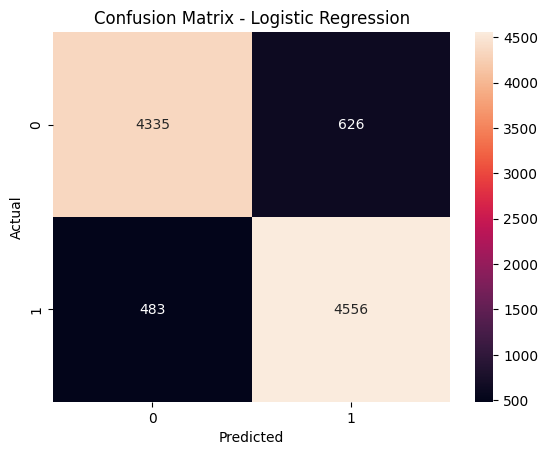

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix. Logistic Regression achieved better overall performance compared to Naive Bayes, with higher accuracy and F1-score. The confusion matrix showed that most predictions were correct, with relatively few misclassifications. This indicates that the model is effective in distinguishing between positive and negative reviews.

# STEP 8: Error Analysis

Analyze incorrect predictions and understand:

- Why the model failed
- What kind of text is difficult

Find Incorrect Predictions

In [ ]:
# Logistic Regression
# Convert to DataFrame for easy analysis
results_df = pd.DataFrame({
    'review': df.loc[y_test.index, 'review'],
    'actual': y_test,
    'predicted': y_pred_lr
})

# Filter wrong predictions
errors = results_df[results_df['actual'] != results_df['predicted']]

# Show some errors
errors.head(5)

,review,actual,predicted
33553,I really liked this Summerslam due to the look...,positive,negative
49498,"Okay, I didn't get the Purgatory thing the fir...",positive,negative
29282,This movie starts off somewhat slowly and gets...,positive,negative
34304,I was first introduced to John Waters films by...,positive,negative
6113,"The production quality, cast, premise, authent...",positive,negative


In [ ]:
# Display Examples Clearly
for i in range(5):
    print("Review:", errors.iloc[i]['review'])
    print("Actual:", errors.iloc[i]['actual'])
    print("Predicted:", errors.iloc[i]['predicted'])
    print("-"*80)

Review: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the Headshrinkers, and Yokozuna defe

In [ ]:
#Count Number of Errors
print("Total incorrect predictions:", len(errors))

Total incorrect predictions: 1109


Error analysis revealed that the model struggled with reviews containing mixed sentiments, sarcasm, and ambiguous language. Short reviews and complex expressions also contributed to misclassification. For example, some reviews contained both positive and negative opinions, making it difficult for the model to assign a single label. Additionally, sarcastic statements were often misinterpreted as positive when they were actually negative.

# STEP 9: Simple Prediction Demo

Allow a user to:

- Enter a movie review
- Get prediction → positive / negative

Create Prediction Function

In [ ]:
def predict_sentiment(review):
    # Step 1: Clean the input
    cleaned = preprocess_text(review)

    # Step 2: Convert to TF-IDF features
    vectorized = tfidf.transform([cleaned])

    # Step 3: Predict using trained model (Logistic Regression)
    prediction = lr_model.predict(vectorized)[0]

    return prediction

Test with Sample Reviews

In [ ]:
print(predict_sentiment("This movie was absolutely fantastic and exciting!"))
print(predict_sentiment("The film was boring and a waste of time"))

positive
negative


Interactive User Input (Simple Demo)

In [ ]:
user_review = input("Enter a movie review: ")

result = predict_sentiment(user_review)

print("Predicted Sentiment:", result)

Enter a movie review: The movies was very terrible
Predicted Sentiment: negative


A simple prediction system was developed to allow users to input a movie review and receive a sentiment classification. The input text is preprocessed, transformed using TF-IDF, and passed into the trained Logistic Regression model to generate a prediction. This demonstrates the practical application of the sentiment analysis model.

# STEP 10: Final Discussion

Summarize:

- Results
- Best model
- Challenges
- Improvements

1. Which Model Performed Best?

From the results:

- Naive Bayes → good but simpler
- Logistic Regression → usually higher accuracy & F1-score


Logistic Regression performed better than Multinomial Naive Bayes in this project. It achieved higher accuracy and F1-score, indicating a better ability to correctly classify both positive and negative reviews. This is because Logistic Regression can capture more complex relationships in the data compared to Naive Bayes.

2. Why Did It Perform Better?

Logistic Regression performed better because it considers relationships between features, while Naive Bayes assumes independence between words. In real-world text data, words are often related, making Logistic Regression more effective.

3. Key Findings

The dataset was balanced, with an equal number of positive and negative reviews. Preprocessing significantly improved the quality of the text data by removing noise such as punctuation, stopwords, and HTML tags. TF-IDF feature extraction helped in identifying important words and improving model performance.

4. Challenges Faced

Several challenges were encountered during the project. The model struggled with reviews containing mixed sentiments, sarcasm, and ambiguous language. Short reviews also made classification difficult due to limited context. Additionally, preprocessing required careful handling to avoid losing important information.

5. Limitations

The model is limited in understanding context, sarcasm, and deeper meanings in language. It relies only on word frequency and does not fully capture sentence structure or tone.

6. Suggestions for Improvement

The model can be improved by using more advanced techniques such as deep learning models (e.g., LSTM or transformers like BERT). Additionally, increasing feature size, tuning hyperparameters, or using word embeddings like Word2Vec could improve performance. Handling sarcasm and context-aware language remains an area for future improvement.

7. Conclusion

In conclusion, this project successfully developed a sentiment analysis system capable of classifying movie reviews as positive or negative. The use of preprocessing techniques and TF-IDF feature extraction significantly improved model performance. Among the models tested, Logistic Regression provided the best results. Despite some limitations, the system demonstrates the effectiveness of NLP techniques in solving real-world text classification problems.